┌─────────────────────────────────────────────────────┐
│                   train_dqn.py                      │
│                                                     │
│  Episode bắt đầu                                    │
│       │                                             │
│       ▼                                             │
│  env.reset() ──────────────► flappy_env.py          │
│       │         state (8D)  (khởi tạo game)         │
│       │◄────────────────────                        │
│       │                                             │
│       ▼                                             │
│  ┌─────────────┐    epsilon-greedy                  │
│  │ DQN.forward │◄── state ──► random action         │
│  │ (online)    │                                    │
│  └──────┬──────┘                                    │
│         │ action (0 hoặc 1)                         │
│         ▼                                           │
│  env.step(action) ─────────► flappy_env.py          │
│         │   next_state,      (cập nhật vật lý,      │
│         │   reward, done     kiểm tra va chạm)      │
│         │◄────────────────────                      │
│         │                                           │
│         ▼                                           │
│  buffer.push(...)           ReplayBuffer            │
│         │                   (lưu transition)        │
│         ▼                                           │
│  compute_td_loss(...)                               │
│    ├── buffer.sample(256)   lấy ngẫu nhiên          │
│    ├── online model → chọn action tốt nhất          │
│    ├── target model → đánh giá Q-value              │
│    ├── Bellman equation → expected Q                │
│    └── MSE loss → backprop → update online model    │
│         │                                           │
│  mỗi 20 ep: target ← online (load_state_dict)       │
│  mỗi 200 ep: lưu .pth                               │
└─────────────────────────────────────────────────────┘

In [1]:
import torch
import numpy as np
import json
from flappy_env import FlappyEnv
from dqn_model import DQN

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

%matplotlib inline

In [ ]:
MODEL_PATH = "./models/flappy_dqn_2800.pth"
NUM_EPISODES = 200
OUTPUT_FILE = "eval_results.json"

In [43]:
def count_pipes(env_log):
    """Đếm số ống vượt qua dựa vào pipe_x transitions."""
    return env_log

In [44]:
def evaluate(model_path, num_episodes):
    env = FlappyEnv()
    model = DQN(8, 256, 2)
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()
 
    results = []
 
    for ep in range(num_episodes):
        state = env.reset()
        total_reward = 0.0
        steps = 0
        pipes_passed = 0
        actions = []
        prev_pipe_x = env.pipe_x
 
        while True:
            with torch.no_grad():
                action = model(torch.tensor(state).float()).argmax().item()
 
            actions.append(action)
            next_state, reward, done = env.step(action)
 
            # Đếm ống vượt qua: pipe_x vừa reset về 450 sau khi ra khỏi màn hình
            if env.pipe_x > prev_pipe_x:
                pipes_passed += 1
            prev_pipe_x = env.pipe_x
 
            total_reward += reward
            steps += 1
            state = next_state
 
            if done:
                break
 
        jump_count = sum(actions)
        jump_rate = jump_count / steps if steps > 0 else 0
 
        results.append({
            "episode": ep,
            "total_reward": round(total_reward, 2),
            "steps": steps,
            "pipes_passed": pipes_passed,
            "jump_count": jump_count,
            "jump_rate": round(jump_rate, 4),
        })
 
        print(f"[{ep+1:>3}/{num_episodes}] reward={total_reward:>8.1f} | "
              f"steps={steps:>5} | pipes={pipes_passed} | jump_rate={jump_rate:.2%}")
 
    # Thống kê tổng hợp
    rewards = [r["total_reward"] for r in results]
    pipes   = [r["pipes_passed"] for r in results]
    steps_l = [r["steps"] for r in results]
    jrates  = [r["jump_rate"] for r in results]
 
    summary = {
        "num_episodes": num_episodes,
        "model_path": model_path,
        "reward": {
            "mean": round(float(np.mean(rewards)), 2),
            "std":  round(float(np.std(rewards)),  2),
            "min":  round(float(np.min(rewards)),  2),
            "max":  round(float(np.max(rewards)),  2),
        },
        "pipes_passed": {
            "mean": round(float(np.mean(pipes)), 2),
            "std":  round(float(np.std(pipes)),  2),
            "min":  int(np.min(pipes)),
            "max":  int(np.max(pipes)),
        },
        "steps": {
            "mean": round(float(np.mean(steps_l)), 2),
            "max":  int(np.max(steps_l)),
        },
        "jump_rate": {
            "mean": round(float(np.mean(jrates)), 4),
            "std":  round(float(np.std(jrates)),  4),
        },
    }
 
    output = {"summary": summary, "episodes": results}
 
    with open(OUTPUT_FILE, "w") as f:
        json.dump(output, f, indent=2)
 
    print("\n" + "="*55)
    print(f"  KẾT QUẢ ĐÁNH GIÁ ({num_episodes} episodes)")
    print("="*55)
    print(f"  Reward   : {summary['reward']['mean']} ± {summary['reward']['std']}")
    print(f"             min={summary['reward']['min']}  max={summary['reward']['max']}")
    print(f"  Pipes    : {summary['pipes_passed']['mean']} ± {summary['pipes_passed']['std']}")
    print(f"             min={summary['pipes_passed']['min']}  max={summary['pipes_passed']['max']}")
    print(f"  Steps    : avg={summary['steps']['mean']}  max={summary['steps']['max']}")
    print(f"  Jump rate: {summary['jump_rate']['mean']:.2%} ± {summary['jump_rate']['std']:.2%}")
    print("="*55)
    print(f"\n  Kết quả đã lưu vào: {OUTPUT_FILE}")

In [45]:
evaluate(MODEL_PATH, NUM_EPISODES)

[  1/200] reward=   260.0 | steps= 1980 | pipes=11 | jump_rate=10.81%
[  2/200] reward=  1551.0 | steps= 9996 | pipes=59 | jump_rate=11.55%
[  3/200] reward= 13309.7 | steps=82972 | pipes=496 | jump_rate=12.37%
[  4/200] reward=   825.3 | steps= 5490 | pipes=32 | jump_rate=11.69%
[  5/200] reward=   932.3 | steps= 6154 | pipes=36 | jump_rate=11.44%
[  6/200] reward=  5184.4 | steps=32547 | pipes=194 | jump_rate=12.24%
[  7/200] reward=  3839.6 | steps=24198 | pipes=144 | jump_rate=12.36%
[  8/200] reward=  5694.2 | steps=35709 | pipes=213 | jump_rate=12.16%
[  9/200] reward=  4807.9 | steps=30209 | pipes=180 | jump_rate=12.29%
[ 10/200] reward=  4699.0 | steps=29534 | pipes=176 | jump_rate=12.09%
[ 11/200] reward=   610.6 | steps= 4158 | pipes=24 | jump_rate=11.74%
[ 12/200] reward=  3812.1 | steps=24025 | pipes=143 | jump_rate=12.35%
[ 13/200] reward=  1117.8 | steps= 7307 | pipes=43 | jump_rate=9.79%
[ 14/200] reward=  1562.8 | steps=10107 | pipes=60 | jump_rate=12.05%
[ 15/200] rewa

In [46]:
with open(OUTPUT_FILE) as f:
    data = json.load(f)

summary  = data["summary"]
episodes = data["episodes"]

eps    = [e["episode"]     for e in episodes]
rewards= [e["total_reward"]for e in episodes]
pipes  = [e["pipes_passed"]for e in episodes]
steps  = [e["steps"]       for e in episodes]
jrates = [e["jump_rate"]   for e in episodes]

print(f"Loaded {len(episodes)} episodes from '{OUTPUT_FILE}'")
print(f"Avg reward: {summary['reward']['mean']} | Avg pipes: {summary['pipes_passed']['mean']}")

Loaded 200 episodes from 'eval_results.json'
Avg reward: 3170.25 | Avg pipes: 119.25


In [47]:
def rolling(arr, w=10):
    result = []
    for i in range(len(arr)):
        start = max(0, i - w + 1)
        result.append(np.mean(arr[start:i+1]))
    return result

BG      = "#0f1117"
PANEL   = "#1a1d27"
ACCENT  = "#00e5ff"
ACCENT2 = "#ff4081"
ACCENT3 = "#69ff47"
ACCENT4 = "#ffd740"
TEXT    = "#e0e0e0"
SUBTEXT = "#888"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   PANEL,
    "axes.edgecolor":   "#2a2d3a",
    "axes.labelcolor":  TEXT,
    "xtick.color":      SUBTEXT,
    "ytick.color":      SUBTEXT,
    "text.color":       TEXT,
    "grid.color":       "#2a2d3a",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "font.family":      "monospace",
})

def stat_box(ax, label, value, sub, color):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")
    rect = FancyBboxPatch((0.05, 0.1), 0.9, 0.8,
                          boxstyle="round,pad=0.05",
                          facecolor=PANEL, edgecolor=color,
                          linewidth=2, zorder=0)
    ax.add_patch(rect)
    ax.text(0.5, 0.72, label, ha="center", va="center", fontsize=10, color=SUBTEXT)
    ax.text(0.5, 0.45, value, ha="center", va="center", fontsize=22,
            fontweight="bold", color=color)
    ax.text(0.5, 0.18, sub,   ha="center", va="center", fontsize=9,  color=SUBTEXT)

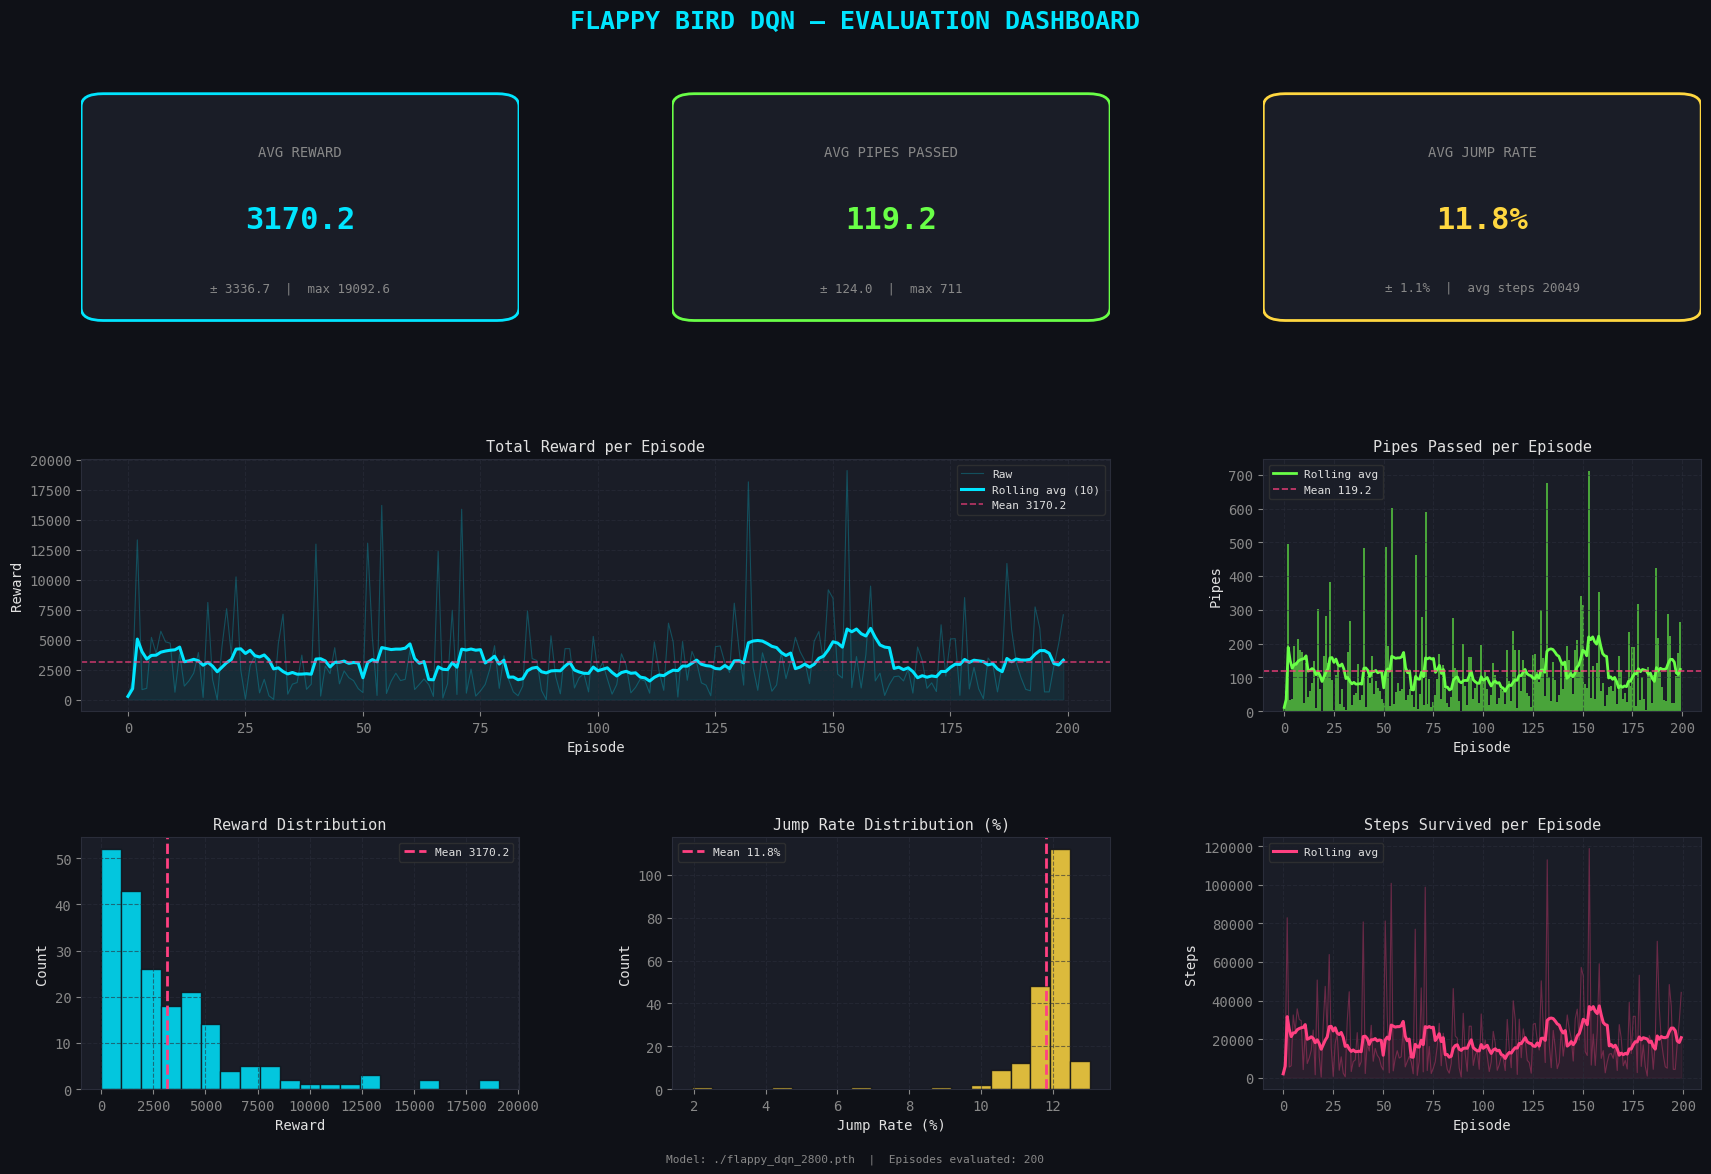

In [48]:
fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle("FLAPPY BIRD DQN — EVALUATION DASHBOARD",
             fontsize=18, fontweight="bold", color=ACCENT,
             y=0.97, fontfamily="monospace")

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35,
                       top=0.91, bottom=0.07, left=0.07, right=0.97)

stat_box(fig.add_subplot(gs[0, 0]),
         "AVG REWARD",
         f"{summary['reward']['mean']:.1f}",
         f"± {summary['reward']['std']:.1f}  |  max {summary['reward']['max']:.1f}",
         ACCENT)

stat_box(fig.add_subplot(gs[0, 1]),
         "AVG PIPES PASSED",
         f"{summary['pipes_passed']['mean']:.1f}",
         f"± {summary['pipes_passed']['std']:.1f}  |  max {summary['pipes_passed']['max']}",
         ACCENT3)

stat_box(fig.add_subplot(gs[0, 2]),
         "AVG JUMP RATE",
         f"{summary['jump_rate']['mean']:.1%}",
         f"± {summary['jump_rate']['std']:.1%}  |  avg steps {summary['steps']['mean']:.0f}",
         ACCENT4)

ax1 = fig.add_subplot(gs[1, :2])
ax1.plot(eps, rewards, color=ACCENT, alpha=0.25, linewidth=0.8, label="Raw")
ax1.plot(eps, rolling(rewards), color=ACCENT, linewidth=2.2, label="Rolling avg (10)")
ax1.axhline(summary["reward"]["mean"], color=ACCENT2, linestyle="--",
            linewidth=1.2, alpha=0.7, label=f"Mean {summary['reward']['mean']:.1f}")
ax1.fill_between(eps, rolling(rewards), alpha=0.08, color=ACCENT)
ax1.set_title("Total Reward per Episode", color=TEXT, fontsize=11)
ax1.set_xlabel("Episode"); ax1.set_ylabel("Reward")
ax1.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax1.grid(True)

ax2 = fig.add_subplot(gs[1, 2])
ax2.bar(eps, pipes, color=ACCENT3, alpha=0.6, width=1.0)
ax2.plot(eps, rolling(pipes), color=ACCENT3, linewidth=2, label="Rolling avg")
ax2.axhline(summary["pipes_passed"]["mean"], color=ACCENT2, linestyle="--",
            linewidth=1.2, alpha=0.8, label=f"Mean {summary['pipes_passed']['mean']:.1f}")
ax2.set_title("Pipes Passed per Episode", color=TEXT, fontsize=11)
ax2.set_xlabel("Episode"); ax2.set_ylabel("Pipes")
ax2.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax2.grid(True)

ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(rewards, bins=20, color=ACCENT, edgecolor=BG, alpha=0.85)
ax3.axvline(summary["reward"]["mean"], color=ACCENT2, linewidth=2,
            linestyle="--", label=f"Mean {summary['reward']['mean']:.1f}")
ax3.set_title("Reward Distribution", color=TEXT, fontsize=11)
ax3.set_xlabel("Reward"); ax3.set_ylabel("Count")
ax3.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax3.grid(True)

ax4 = fig.add_subplot(gs[2, 1])
ax4.hist([r * 100 for r in jrates], bins=20, color=ACCENT4, edgecolor=BG, alpha=0.85)
ax4.axvline(summary["jump_rate"]["mean"] * 100, color=ACCENT2, linewidth=2,
            linestyle="--", label=f"Mean {summary['jump_rate']['mean']:.1%}")
ax4.set_title("Jump Rate Distribution (%)", color=TEXT, fontsize=11)
ax4.set_xlabel("Jump Rate (%)"); ax4.set_ylabel("Count")
ax4.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax4.grid(True)

ax5 = fig.add_subplot(gs[2, 2])
ax5.plot(eps, steps, color=ACCENT2, alpha=0.35, linewidth=0.8)
ax5.plot(eps, rolling(steps), color=ACCENT2, linewidth=2.2, label="Rolling avg")
ax5.fill_between(eps, rolling(steps), alpha=0.07, color=ACCENT2)
ax5.set_title("Steps Survived per Episode", color=TEXT, fontsize=11)
ax5.set_xlabel("Episode"); ax5.set_ylabel("Steps")
ax5.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax5.grid(True)

fig.text(0.5, 0.01,
         f"Model: {summary['model_path']}  |  Episodes evaluated: {summary['num_episodes']}",
         ha="center", fontsize=8, color=SUBTEXT)

plt.show()

In [49]:
TRAIN_LOG  = "train_log.json"

with open(TRAIN_LOG) as f:
    log = json.load(f)

eps      = [e["episode"] for e in log]
rewards  = [e["reward"]  for e in log]
epsilons = [e["epsilon"] for e in log]
lrs      = [e["lr"]      for e in log]

print(f"Loaded {len(log)} episodes")
print(f"Episode cuối : {eps[-1]}")
print(f"Reward cuối  : {rewards[-1]:.1f}")
print(f"Epsilon cuối : {epsilons[-1]:.4f}")
print(f"LR cuối      : {lrs[-1]:.2e}")

Loaded 3000 episodes
Episode cuối : 2999
Reward cuối  : -40.8
Epsilon cuối : 0.0500
LR cuối      : 1.00e-04


In [50]:
def rolling(arr, w=20):
    result = []
    for i in range(len(arr)):
        start = max(0, i - w + 1)
        result.append(np.mean(arr[start:i+1]))
    return result

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   PANEL,
    "axes.edgecolor":   "#2a2d3a",
    "axes.labelcolor":  TEXT,
    "xtick.color":      SUBTEXT,
    "ytick.color":      SUBTEXT,
    "text.color":       TEXT,
    "grid.color":       "#2a2d3a",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "font.family":      "monospace",
})

def stat_box(ax, label, value, sub, color):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")
    from matplotlib.patches import FancyBboxPatch
    rect = FancyBboxPatch((0.05, 0.1), 0.9, 0.8,
                          boxstyle="round,pad=0.05",
                          facecolor=PANEL, edgecolor=color,
                          linewidth=2, zorder=0)
    ax.add_patch(rect)
    ax.text(0.5, 0.72, label, ha="center", va="center", fontsize=10, color=SUBTEXT)
    ax.text(0.5, 0.45, value, ha="center", va="center", fontsize=20,
            fontweight="bold", color=color)
    ax.text(0.5, 0.18, sub,   ha="center", va="center", fontsize=9,  color=SUBTEXT)

print("Theme & helpers ready")

Theme & helpers ready


/media/malware/Data/VKU/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/media/malware/Data/VKU/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7888 (\N{LATIN CAPITAL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/media/malware/Data/VKU/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7855 (\N{LATIN SMALL LETTER A WITH BREVE AND ACUTE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/media/malware/Data/VKU/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7847 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND GRAVE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/media/malw

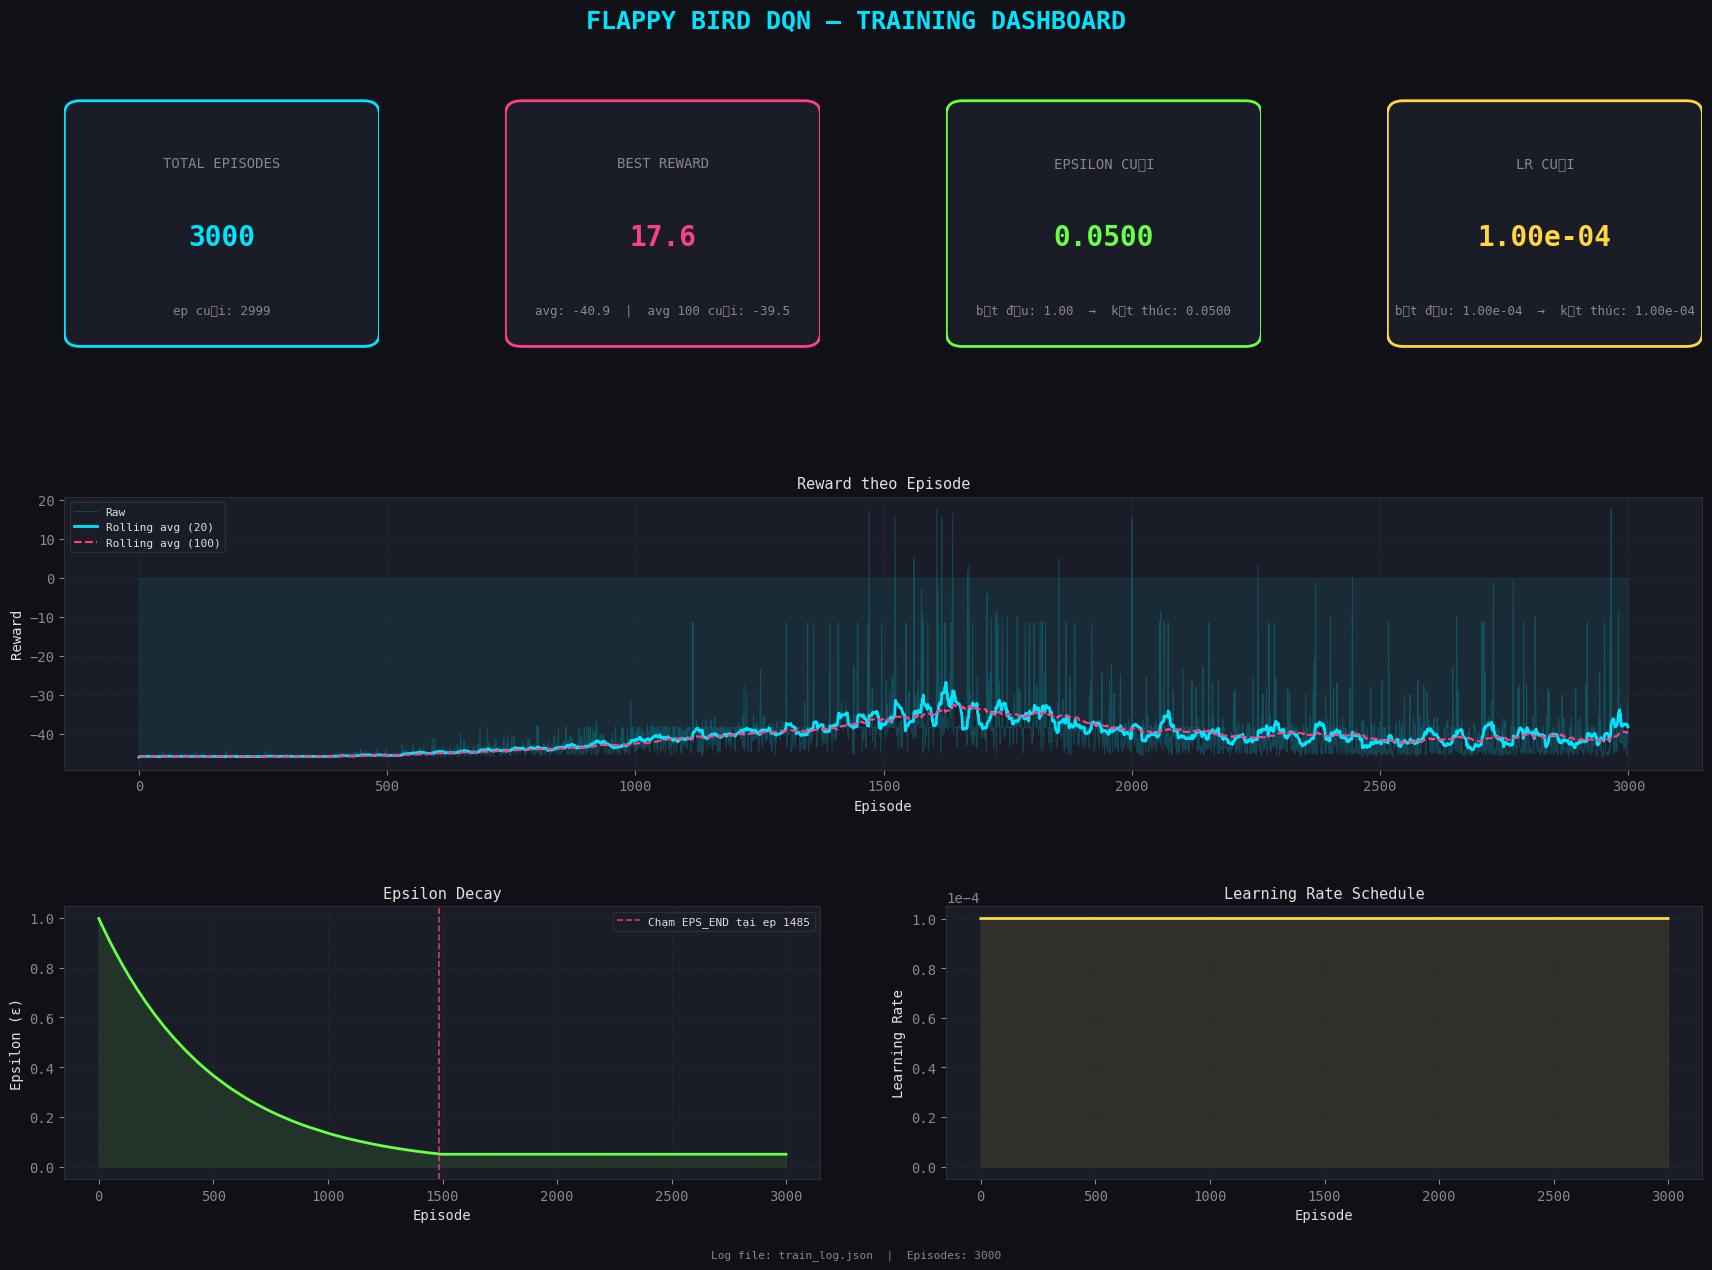

In [51]:
# Cell 4: Vẽ Training Dashboard
fig = plt.figure(figsize=(18, 13), facecolor=BG)
fig.suptitle("FLAPPY BIRD DQN — TRAINING DASHBOARD",
             fontsize=18, fontweight="bold", color=ACCENT,
             y=0.97, fontfamily="monospace")

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4,
                       top=0.91, bottom=0.07, left=0.06, right=0.97)

# ── Row 0: Stat boxes ────────────────────────────────────────────────────────
stat_box(fig.add_subplot(gs[0, 0]),
         "TOTAL EPISODES",
         f"{len(eps)}",
         f"ep cuối: {eps[-1]}",
         ACCENT)

stat_box(fig.add_subplot(gs[0, 1]),
         "BEST REWARD",
         f"{max(rewards):.1f}",
         f"avg: {np.mean(rewards):.1f}  |  avg 100 cuối: {np.mean(rewards[-100:]):.1f}",
         ACCENT2)

stat_box(fig.add_subplot(gs[0, 2]),
         "EPSILON CUỐI",
         f"{epsilons[-1]:.4f}",
         f"bắt đầu: {epsilons[0]:.2f}  →  kết thúc: {epsilons[-1]:.4f}",
         ACCENT3)

stat_box(fig.add_subplot(gs[0, 3]),
         "LR CUỐI",
         f"{lrs[-1]:.2e}",
         f"bắt đầu: {lrs[0]:.2e}  →  kết thúc: {lrs[-1]:.2e}",
         ACCENT4)

# ── Row 1 full: Reward theo episode ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, :])
ax1.plot(eps, rewards, color=ACCENT, alpha=0.2, linewidth=0.7, label="Raw")
ax1.plot(eps, rolling(rewards, 20),  color=ACCENT,  linewidth=2.0, label="Rolling avg (20)")
ax1.plot(eps, rolling(rewards, 100), color=ACCENT2, linewidth=1.5,
         linestyle="--", label="Rolling avg (100)")
ax1.fill_between(eps, rolling(rewards, 20), alpha=0.07, color=ACCENT)
ax1.set_title("Reward theo Episode", color=TEXT, fontsize=11)
ax1.set_xlabel("Episode")
ax1.set_ylabel("Reward")
ax1.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax1.grid(True)

# ── Row 2 left: Epsilon decay ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[2, :2])
ax2.plot(eps, epsilons, color=ACCENT3, linewidth=2)
ax2.fill_between(eps, epsilons, alpha=0.1, color=ACCENT3)
# Đánh dấu điểm epsilon chạm EPS_END
eps_end_idx = next((i for i, e in enumerate(epsilons) if e <= 0.051), None)
if eps_end_idx:
    ax2.axvline(eps[eps_end_idx], color=ACCENT2, linestyle="--",
                linewidth=1.2, alpha=0.8,
                label=f"Chạm EPS_END tại ep {eps[eps_end_idx]}")
    ax2.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax2.set_title("Epsilon Decay", color=TEXT, fontsize=11)
ax2.set_xlabel("Episode")
ax2.set_ylabel("Epsilon (ε)")
ax2.grid(True)

# ── Row 2 right: Learning rate schedule ──────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 2:])
ax3.plot(eps, lrs, color=ACCENT4, linewidth=2)
ax3.fill_between(eps, lrs, alpha=0.1, color=ACCENT4)
# Đánh dấu các mốc LR giảm (step_size=500)
lr_changes = [i for i in range(1, len(lrs)) if lrs[i] < lrs[i-1] * 0.9]
for idx in lr_changes:
    ax3.axvline(eps[idx], color=ACCENT2, linestyle=":",
                linewidth=1.0, alpha=0.6)
ax3.set_title("Learning Rate Schedule", color=TEXT, fontsize=11)
ax3.set_xlabel("Episode")
ax3.set_ylabel("Learning Rate")
ax3.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax3.grid(True)

# ── Footer ────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.01,
         f"Log file: {TRAIN_LOG}  |  Episodes: {len(eps)}",
         ha="center", fontsize=8, color=SUBTEXT)

plt.show()